<a href="https://colab.research.google.com/github/ADITI9981/Deep_Learning/blob/main/transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub


from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


In [2]:
Image_Shape = (224, 224)

classifier = tf.keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4",
                   input_shape=Image_Shape + (3,))
])

In [3]:
print("TF Version:", tf.__version__)
print("TF Hub Version:", hub.__version__)

TF Version: 2.12.0
TF Hub Version: 0.13.0


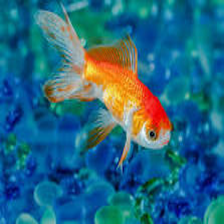

In [5]:
gold_fish = Image.open("goldfish.jpg").resize(Image_Shape)
gold_fish

In [6]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [7]:
gold_fish[np.newaxis, ...].shape

(1, 224, 224, 3)

In [10]:
result = classifier.predict(gold_fish[np.newaxis, ...])
result.shape

1/1 [==============================] - 0s 95ms/step


(1, 1001)

In [11]:
result

array([[ 0.2589297 ,  2.8211322 , 10.517104  , ..., -2.196119  ,
         0.5345841 , -0.50153494]], dtype=float32)

In [12]:
predicted_label_index = np.argmax(result)
predicted_label_index

2

In [14]:
with open("ImageNetLabels.txt","r") as f:
  image_labels = f.read().splitlines()
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [15]:
image_labels[predicted_label_index]

'goldfish'

In [16]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# Re-download and extract the dataset
data_dir = tf.keras.utils.get_file(
    'flower_photos',
    origin=dataset_url,
    cache_dir='/tmp/.keras/datasets',  # The directory where the dataset will be stored
    untar=True  # Automatically extract the dataset
)

print("Dataset downloaded and extracted to:", data_dir)

228813984/228813984 [==============================] - 3s 0us/step
Dataset downloaded and extracted to: /tmp/.keras/datasets/flower_photos


In [19]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('/tmp/.keras/datasets/flower_photos')

In [20]:
list(data_dir.glob('*.jpg'))[:5]


[]

In [21]:
# List all .jpg files in the flower categories subdirectories
jpg_files = list(data_dir.rglob('*.jpg'))

# Print the list of .jpg files
image_count=len(jpg_files)
image_count

3670

In [22]:
roses=list(data_dir.rglob('roses/*'))
roses[:5]

[PosixPath('/tmp/.keras/datasets/flower_photos/roses/8524505546_b242bd4928_n.jpg'),
 PosixPath('/tmp/.keras/datasets/flower_photos/roses/1446097778_97149b8362.jpg'),
 PosixPath('/tmp/.keras/datasets/flower_photos/roses/4951581805_b049304f1b_n.jpg'),
 PosixPath('/tmp/.keras/datasets/flower_photos/roses/22325299158_6e32e599f8_m.jpg'),
 PosixPath('/tmp/.keras/datasets/flower_photos/roses/15255964274_cf2ecdf702.jpg')]

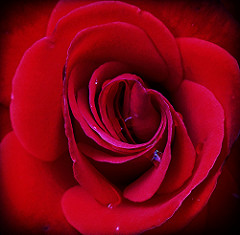

In [23]:
Image.open(str(roses[3]))

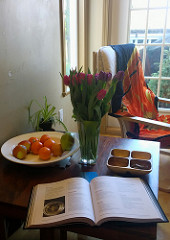

In [24]:
tulips=list(data_dir.rglob('tulips/*'))
Image.open(str(tulips[1]))

In [25]:
flower_images_dic = {
    'roses': list(data_dir.rglob('roses/*')),
    'daisy': list(data_dir.rglob('daisy/*')),
    'dandelion': list(data_dir.rglob('dandelion/*')),
    'sunflowers': list(data_dir.rglob('sunflowers/*')),
    'tulips': list(data_dir.rglob('tulips/*')),
}

In [26]:
flower_labels_dict={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}


In [27]:
img = cv2.imread(str(flower_images_dic['roses'][0]))
img.shape

(256, 320, 3)

In [39]:
cv2.resize(img,Image_Shape).shape

(224, 224, 3)

In [40]:
x,y=[],[]

for flower_name,images in flower_images_dic.items():
    for image in images:
        img=cv2.imread(str(image))
        resized_img=cv2.resize(img,Image_Shape)
        x.append(resized_img)
        y.append(flower_labels_dict[flower_name])

In [41]:
x=np.array(x)
y=np.array(y)

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0)

In [43]:
x_train_scaled=x_train/255
x_test_scaled=x_test/255

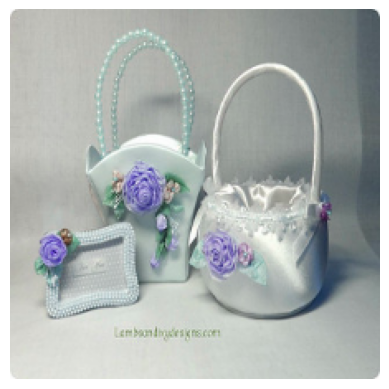

In [44]:
plt.axis('off')
plt.imshow(x[0])

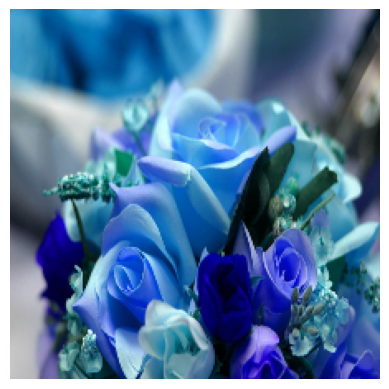

In [45]:
plt.axis('off')
plt.imshow(x[1])

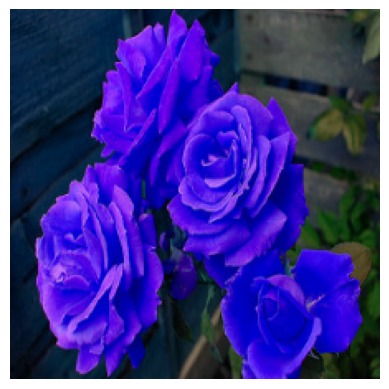

In [46]:
plt.axis('off')
plt.imshow(x[2])

In [48]:
predicted = classifier.predict(np.array([x[0],x[1],x[2]]))
predicted = np.argmax(predicted,axis=1)
predicted

1/1 [==============================] - 0s 106ms/step


array([722, 795, 722])

In [49]:
image_labels[795]

'shower curtain'

In [50]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False
)

In [51]:
num_of_flower = 5

model = tf.keras.Sequential([
    pretrained_model_without_top_layer,
    tf.keras.layers.Dense(num_of_flower)
])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 5)                 6405      
                                                                 
Total params: 2,264,389
Trainable params: 6,405
Non-trainable params: 2,257,984
_________________________________________________________________


In [52]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["acc"]
)
model.fit(x_train_scaled,y_train,epochs=5)

Epoch 1/5
86/86 [==============================] - 103s 1s/step - loss: 0.8708 - acc: 0.6730
Epoch 2/5
86/86 [==============================] - 96s 1s/step - loss: 0.4350 - acc: 0.8510
Epoch 3/5
86/86 [==============================] - 94s 1s/step - loss: 0.3378 - acc: 0.8855
Epoch 4/5
86/86 [==============================] - 110s 1s/step - loss: 0.2819 - acc: 0.9121
Epoch 5/5
86/86 [==============================] - 97s 1s/step - loss: 0.2427 - acc: 0.9270


In [53]:
model.evaluate(x_test_scaled,y_test)

29/29 [==============================] - 34s 1s/step - loss: 0.3277 - acc: 0.8824


[0.3277292549610138, 0.8823529481887817]